# Lending Club Loan Default Prediction
## A Deep Learning approach to predict loan defaults using Keras & TensorFlow

### Sections:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Building
4. Model Evaluation

In [3]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [41]:
#loading the dataset 
# lending_club_info.csv contains feature descriptions
# lending_club_loan_two.csv is our main dataset

#loading feature description for easy lookup
data_info = pd.read_csv('../data/lending_club_info.csv', index_col='LoanStatNew')

# Helper function to print description of any column
def feat_info(col_name):
    print(data_info.loc[col_name]['Description'])

# Load the main dataset
df = pd.read_csv('../data/lending_club_loan_two.csv')

# Quick look at the data shape and column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

## 1.EDA 

In [5]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [6]:
df['loan_status']

0          Fully Paid
1          Fully Paid
2          Fully Paid
3          Fully Paid
4         Charged Off
             ...     
396025     Fully Paid
396026     Fully Paid
396027     Fully Paid
396028     Fully Paid
396029     Fully Paid
Name: loan_status, Length: 396030, dtype: str

<Axes: xlabel='loan_status', ylabel='count'>

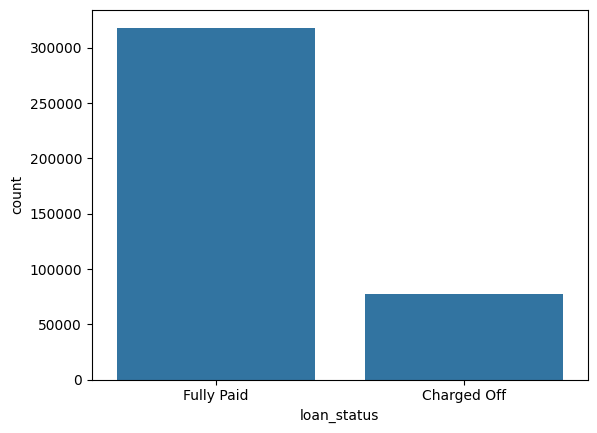

In [7]:
# TARGET VARIABLE DISTRIBUTION
# See how many loans were Fully Paid vs Charged Off
# This tells us if our dataset is imbalanced
sns.countplot(x = 'loan_status', data=df)

Text(0.5, 1.0, 'Distribution of Loan Amount')

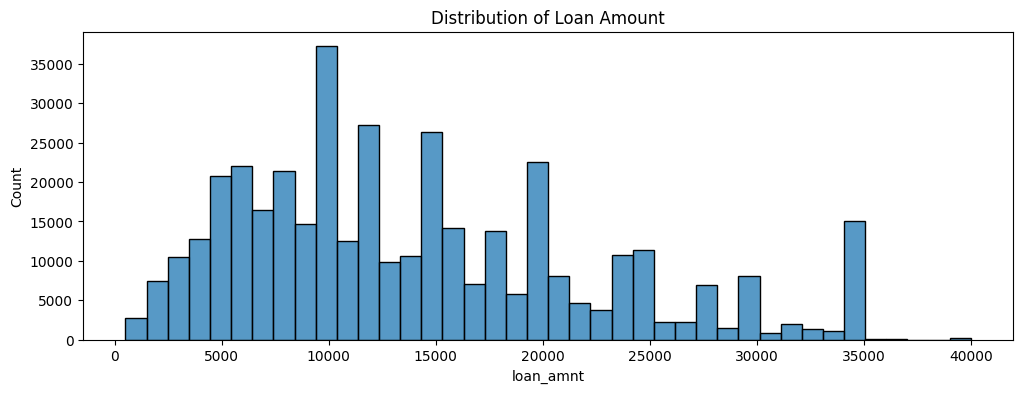

In [9]:
# LOAN AMOUNT DISTRIBUTION
# Understanding the range and spread of loan amounts
plt.figure(figsize=(12,4))
sns.histplot(df['loan_amnt'], bins=40)
plt.title('Distribution of Loan Amount')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

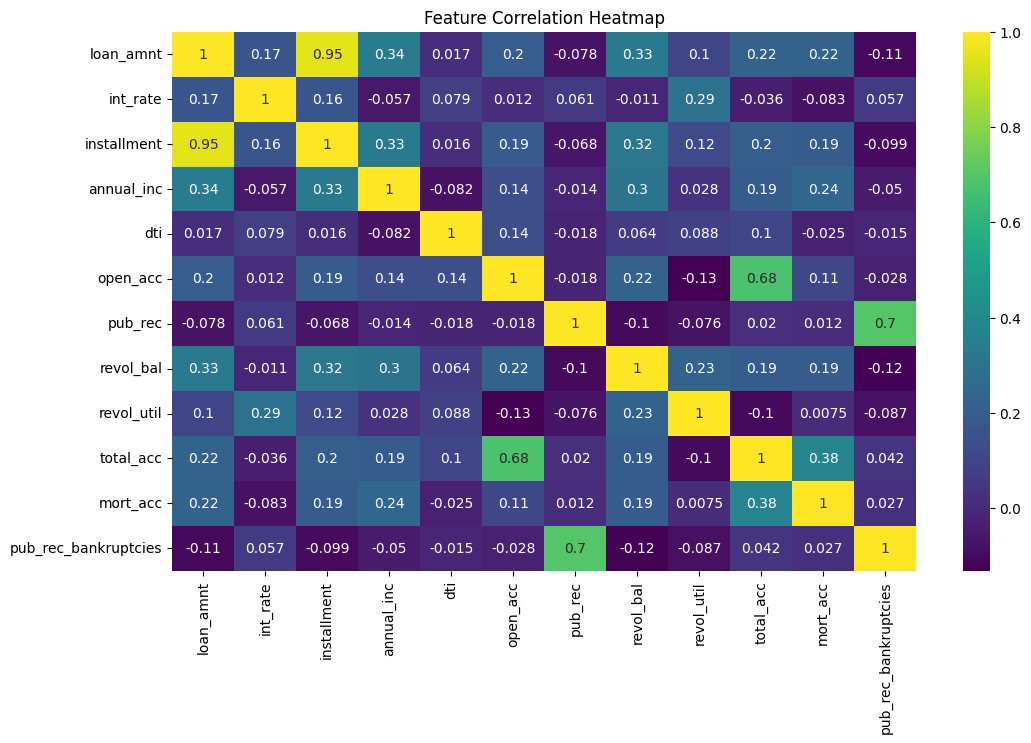

In [15]:
# CORRELATION MATRIX
# Check which numeric features are correlated
# with each other — helps spot redundant features
plt.figure(figsize=(12, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')

plt.title('Feature Correlation Heatmap')

In [17]:
# INSTALLMENT vs LOAN AMOUNT
# These two are almost perfectly correlated
# meaning they carry duplicate information
# We'll decide whether to drop one later
feat_info('installment')
print('\n')
feat_info('loan_amnt')

The monthly payment owed by the borrower if the loan originates.


The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.


Text(0.5, 1.0, 'Installment vs Loan Amount')

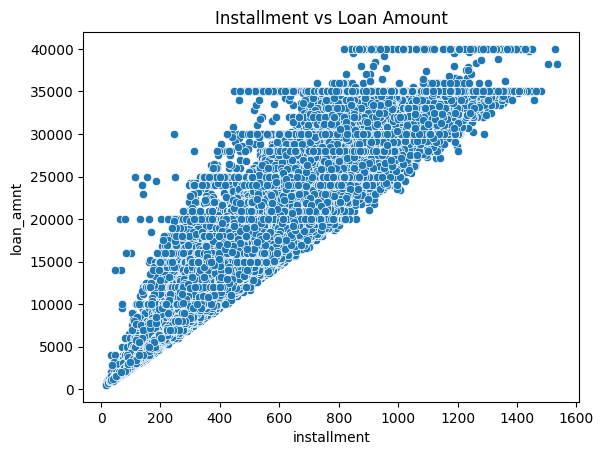

In [18]:
# Scatterplot to visually confirm the correlation
sns.scatterplot(x='installment', y='loan_amnt', data=df)
plt.title('Installment vs Loan Amount')

Text(0.5, 1.0, 'Loan Amount by Loan Status')

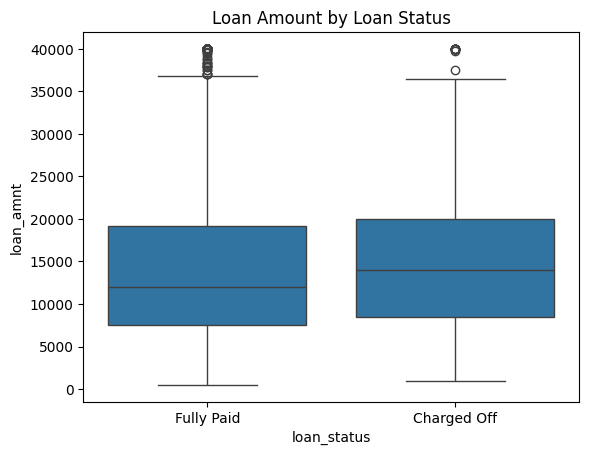

In [19]:
# LOAN AMOUNT vs LOAN STATUS
# Do people who default tend to borrow more?
# Boxplot shows median, spread and outliers

sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Loan Amount by Loan Status')

In [22]:
# Summary statistics grouped by loan status
#this is numeric interpretation of the boxplot
df.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


In [24]:
# Unique grades and subgrades columns
print(sorted(df['grade'].unique()))
print(sorted(df['sub_grade'].unique()))


['A', 'B', 'C', 'D', 'E', 'F', 'G']
['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


<Axes: xlabel='grade', ylabel='count'>

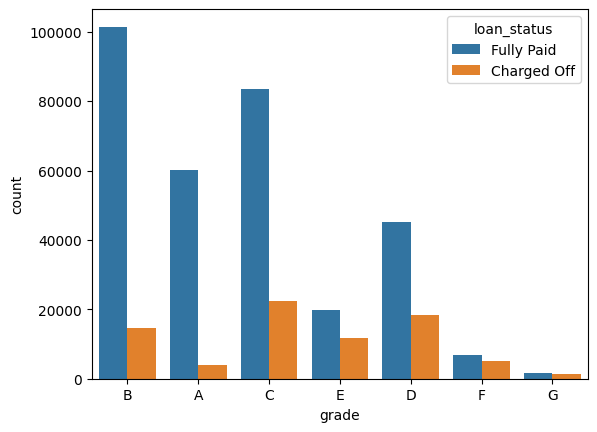

In [25]:
#countplot per grade, colored by loan status
sns.countplot(x='grade', data=df, hue='loan_status')

Text(0.5, 1.0, 'Loan Count per Subgrade')

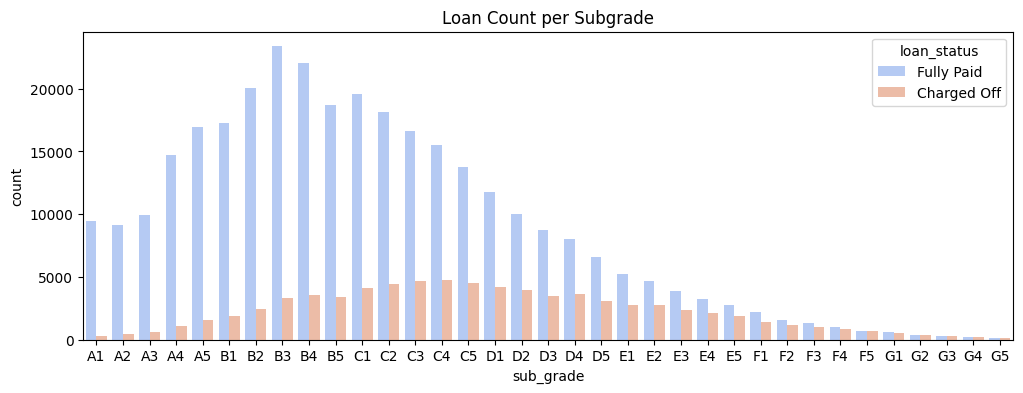

In [26]:
# More detailed — countplot per subgrade
plt.figure(figsize=(12, 4))
subgrade_order = sorted(df['sub_grade'].unique())
sns.countplot(x='sub_grade', data=df, order=subgrade_order,
              palette='coolwarm', hue='loan_status')
plt.title('Loan Count per Subgrade')

Text(0.5, 1.0, 'F & G Subgrade Loan Status')

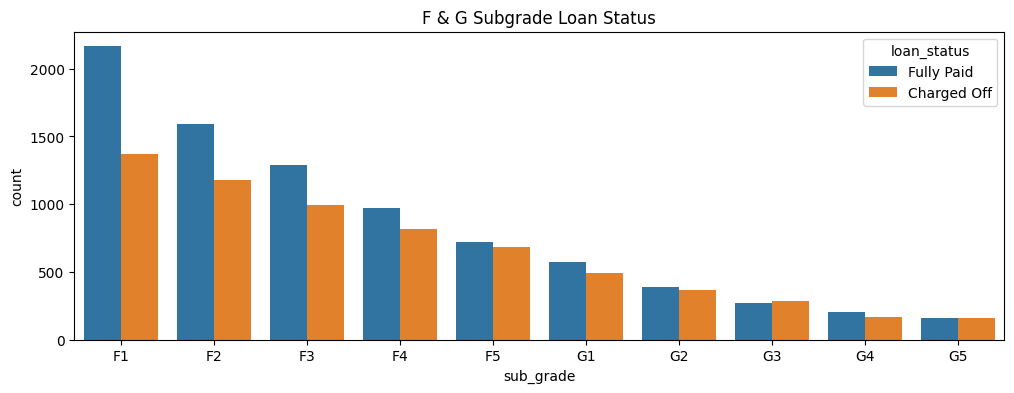

In [27]:
# F & G SUBGRADES
# These seem to have higher default rates
# Let's isolate 
f_and_g = df[(df['grade'] == 'G') | (df['grade'] == 'F')]

plt.figure(figsize=(12, 4))
subgrade_order = sorted(f_and_g['sub_grade'].unique())
sns.countplot(x='sub_grade', data=f_and_g, order=subgrade_order, hue='loan_status')
plt.title('F & G Subgrade Loan Status')

In [29]:
# CREATE BINARY TARGET COLUMN
# 1 = Fully Paid (good)
# 0 = Charged Off (default)
# This will be our y label for the model
df['loan_repaid'] = df['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})

#the targets are mapped to 1 or 0
df[['loan_repaid', 'loan_status']].head()

,loan_repaid,loan_status
0,1,Fully Paid
1,1,Fully Paid
2,1,Fully Paid
3,1,Fully Paid
4,0,Charged Off


Text(0.5, 1.0, 'Feature Correlation with Loan Repaid')

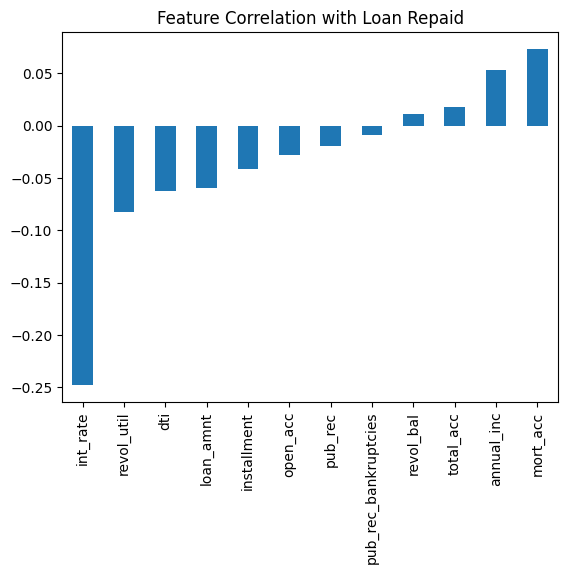

In [32]:
# CORRELATION WITH TARGET
# Which features are most correlated with
# whether a loan gets repaid?
# Negative = more likely to default
df.corr(numeric_only=True)['loan_repaid'].sort_values().drop('loan_repaid').plot(kind='bar')
plt.title('Feature Correlation with Loan Repaid')

## 2.Data Preprocessing

In [34]:
# MISSING DATA ANALYSIS
# First understanding the scale of missing data
# before deciding how to handle it


#total length of the dataframe
print(f"Total rows:{len(df)}")

#count of missing values per column 
print(f"Missing value counts")
df.isnull().sum()


Total rows:396030
Missing value counts


loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
loan_repaid                 0
dtype: int64

In [35]:
#print missing value percentage
print("Missing value percentages:")
100 * df.isnull().sum() / len(df)

Missing value percentages:


loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
installment             0.000000
grade                   0.000000
sub_grade               0.000000
emp_title               5.789208
emp_length              4.621115
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.443401
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.069692
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                9.543469
pub_rec_bankruptcies    0.135091
address                 0.000000
loan_repaid             0.000000
dtype: float64

In [36]:
feat_info('emp_title')
print('\n')
feat_info('emp_length')

The job title supplied by the Borrower when applying for the loan.*


Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 


In [37]:
df['emp_title'].nunique()

173105

In [38]:
df['emp_title'].value_counts()

emp_title
Teacher                      4389
Manager                      4250
Registered Nurse             1856
RN                           1846
Supervisor                   1830
                             ... 
Retirement Counselor            1
Data Center Specialist II       1
Michael's Arts & Crafts         1
licensed bankere                1
Gracon Services, Inc            1
Name: count, Length: 173105, dtype: int64

In [42]:
# emp_title: Too many unique values (173,000+)
# to be useful as a categorical feature
# We can't convert this to dummies meaningfully
df = df.drop('emp_title', axis=1)

In [54]:
df['emp_length'].unique()
#nan is also there, so we should drop the nulls

<StringArray>
['10+ years',   '4 years',  '< 1 year',   '6 years',   '9 years',   '2 years',
   '3 years',   '8 years',   '7 years',   '5 years',    '1 year',         nan]
Length: 12, dtype: str

In [55]:
sorted(df['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

Text(0.5, 1.0, 'Loan Status by Employment Length')

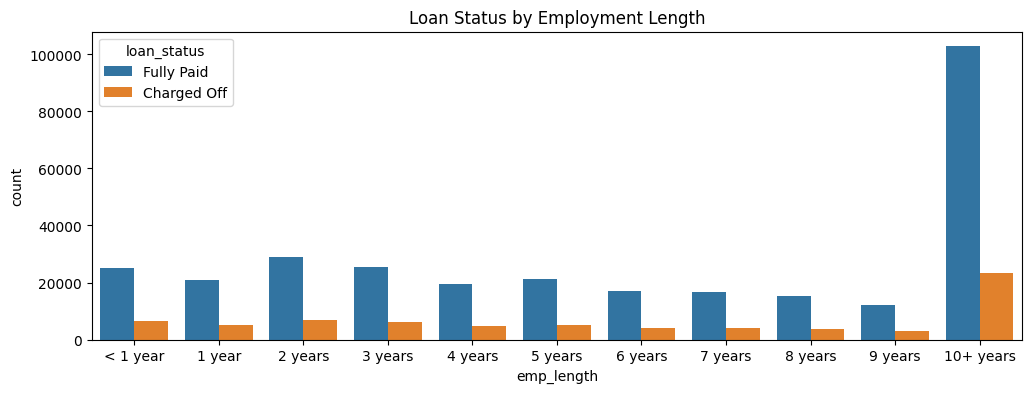

In [56]:
# emp_length: Check if employment length
# actually affects default rate
emp_length_order = ['< 1 year','1 year','2 years','3 years','4 years',
                    '5 years','6 years','7 years','8 years','9 years','10+ years']

plt.figure(figsize=(12, 4))
sns.countplot(x='emp_length', data=df, order=emp_length_order, hue='loan_status')
plt.title('Loan Status by Employment Length')

Text(0.5, 1.0, 'Charge Off Rate by Employment Length')

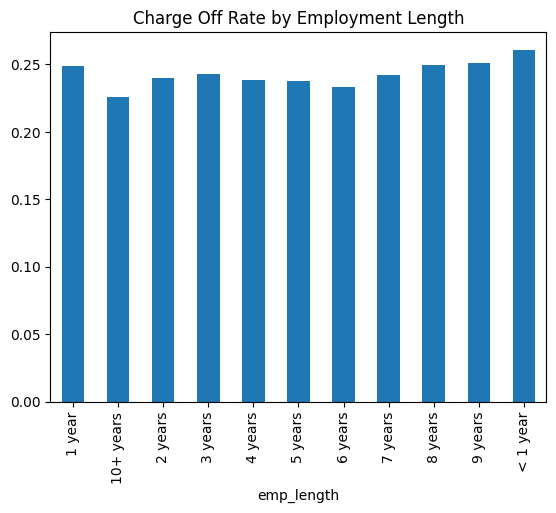

In [64]:
# Calculate charge off RATE per employment length
# If rates are similar across all lengths,
# the feature adds no predictive value

emp_co = df[df['loan_status'] == "Charged Off"].groupby("emp_length").count()['loan_status']
emp_fp = df[df['loan_status'] == "Fully Paid"].groupby("emp_length").count()['loan_status']

# Ratio of charge offs to fully paid per employment length
emp_len = emp_co / emp_fp
emp_len.plot(kind='bar')
plt.title('Charge Off Rate by Employment Length')

In [65]:
# Charge off rates are very similar across all lengths
# So this feature has low predictive power dropping it
df = df.drop('emp_length', axis=1)

In [67]:
df['purpose'].unique()

<StringArray>
[          'vacation', 'debt_consolidation',        'credit_card',
   'home_improvement',     'small_business',     'major_purchase',
              'other',            'medical',            'wedding',
                'car',             'moving',              'house',
        'educational',   'renewable_energy']
Length: 14, dtype: str

In [68]:
df['title'].unique()

<StringArray>
[                                              'Vacation',
                                     'Debt consolidation',
                                'Credit card refinancing',
                                  'Credit Card Refinance',
                                       'Home improvement',
                                   'No More Credit Cards',
                                     'Debt Consolidation',
                                               'Business',
                                         'Major purchase',
                        'Debt Consolidation/Home Repairs',
 ...
                                      'credit card pyoff',
                                  'Consolidate all Loans',
                                        'Creit CArd Refi',
 'Home Improvement to make Home Green (Energy Efficient)',
                                                'Cc Debt',
                            'Outboard Motor Repower Loan',
                  '2011 Insurance and

In [69]:
# title vs purpose:
# 'title' is just a free-text version of 'purpose'
# They carry the same information — drop title

df = df.drop('title', axis=1)

In [71]:
# mort_acc: Number of mortgage accounts
# Has the most missing values (~10%)
# Instead of dropping rows or filling with mean,
# we'll fill based on the correlated 'total_acc' column
print("Correlation with mort_acc:")
df.corr(numeric_only=True)['mort_acc'].sort_values()

Correlation with mort_acc:


int_rate               -0.082583
dti                    -0.025439
revol_util              0.007514
pub_rec                 0.011552
pub_rec_bankruptcies    0.027239
open_acc                0.109205
installment             0.193694
revol_bal               0.194925
loan_amnt               0.222315
annual_inc              0.236320
total_acc               0.381072
mort_acc                1.000000
Name: mort_acc, dtype: float64

In [75]:
df.groupby('total_acc').mean(numeric_only=True)['mort_acc']

total_acc
2.0      0.000000
3.0      0.052023
4.0      0.066743
5.0      0.103289
6.0      0.151293
           ...   
124.0    1.000000
129.0    1.000000
135.0    3.000000
150.0    2.000000
151.0    0.000000
Name: mort_acc, Length: 118, dtype: float64

In [76]:
# Calculate mean mort_acc for each total_acc value
# This gives us a smarter fill value per row
total_acc_avg = df.groupby('total_acc').mean(numeric_only=True)['mort_acc']
print("Mean mort_acc per total_acc value:")
print(total_acc_avg.head(10))

Mean mort_acc per total_acc value:
total_acc
2.0     0.000000
3.0     0.052023
4.0     0.066743
5.0     0.103289
6.0     0.151293
7.0     0.221695
8.0     0.308422
9.0     0.365499
10.0    0.429158
11.0    0.526570
Name: mort_acc, dtype: float64


In [77]:
# Fill missing mort_acc values:
# If mort_acc is NaN → replace with the average
# mort_acc for that row's total_acc value
# This is smarter than a global mean fill

def fill_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc):
        # Return the average mort_acc for this total_acc group
        return total_acc_avg[total_acc]
    else:
        # Keep the original value if not missing
        return mort_acc

df['mort_acc'] = df.apply(lambda x: fill_mort_acc(x['total_acc'], x['mort_acc']), axis=1)

# Verify mort_acc no longer has missing values
print("Missing after fill:", df['mort_acc'].isnull().sum())

Missing after fill: 0


In [78]:
#how many columns we have now for missing data
df.isnull().sum()

loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
home_ownership            0
annual_inc                0
verification_status       0
issue_d                   0
loan_status               0
purpose                   0
dti                       0
earliest_cr_line          0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util              276
total_acc                 0
initial_list_status       0
application_type          0
mort_acc                  0
pub_rec_bankruptcies    535
address                   0
dtype: int64

In [79]:
#this is not a large portion of data , so we can drop this null values
df = df.dropna()

In [80]:
df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
dtype: int64

## Categorical Variables and Dummy Variables

In [83]:
#checking columns that are non numeric
df.select_dtypes(['object']).columns

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29084\1583519108.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(['object']).columns


Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'earliest_cr_line',
       'initial_list_status', 'application_type', 'address'],
      dtype='str')

In [84]:
#checking the 'term' column
df['term'].value_counts()

term
36 months    301247
60 months     93972
Name: count, dtype: int64

In [86]:
#converting the term columns entry to numeric
df['term'] = df['term'].apply(lambda term: int(term[:3]))
df['term'].value_counts()

term
36    301247
60     93972
Name: count, dtype: int64

In [87]:
#'grade' is already contained in 'subgrade' , so we can drop it
df = df.drop('grade', axis=1)

In [88]:
# sub_grade: Convert to dummy variables
# drop_first=True avoids multicollinearity
# (dummy variable trap)

subgrade_dummies = pd.get_dummies(df['sub_grade'], drop_first=True,)

In [89]:
subgrade_dummies

,A2,A3,A4,A5,B1,B2,B3,B4,B5,C1,...,F1,F2,F3,F4,F5,G1,G2,G3,G4,G5
0,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
396026,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
396027,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396028,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [91]:
#concatenating the dummy cols with the actual df
df = pd.concat([df.drop('sub_grade',axis=1), subgrade_dummies], axis = 1)

In [92]:
df.select_dtypes('object').columns

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29084\258164279.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').columns


Index(['home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='str')

In [94]:
df['verification_status'].value_counts()

verification_status
Verified           139451
Source Verified    131301
Not Verified       124467
Name: count, dtype: int64

In [95]:
df['application_type'].value_counts()

application_type
INDIVIDUAL    394508
JOINT            425
DIRECT_PAY       286
Name: count, dtype: int64

In [96]:
df['initial_list_status'].value_counts()

initial_list_status
f    237346
w    157873
Name: count, dtype: int64

In [97]:
df['purpose'].value_counts()

purpose
debt_consolidation    234169
credit_card            82923
home_improvement       23961
other                  21059
major_purchase          8756
small_business          5656
car                     4670
medical                 4175
moving                  2842
vacation                2442
house                   2197
wedding                 1794
renewable_energy         329
educational              246
Name: count, dtype: int64

In [98]:
# verification_status, application_type,
# initial_list_status, purpose:
# All low-cardinality categoricals → dummies
dummies = pd.get_dummies(df[['verification_status','application_type',
                              'initial_list_status','purpose']], drop_first=True)
df = df.drop(['verification_status','application_type',
              'initial_list_status','purpose'], axis=1)
df = pd.concat([df, dummies], axis=1)

In [99]:
df.select_dtypes('object').columns

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29084\258164279.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').columns


Index(['home_ownership', 'issue_d', 'loan_status', 'earliest_cr_line',
       'address'],
      dtype='str')

In [100]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          110
NONE            29
ANY              3
Name: count, dtype: int64

In [101]:
#NONE and ANY categories → OTHER
df['home_ownership'] = df['home_ownership'].replace(['NONE','ANY'],'OTHER')

In [102]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          142
Name: count, dtype: int64

In [103]:
dummies = pd.get_dummies(df['home_ownership'], drop_first=True)
df = pd.concat([df.drop('home_ownership',axis=1),dummies],axis=1)

In [104]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'issue_d',
       'loan_status', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies', 'address', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2',
       'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4',
       'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1',
       'G2', 'G3', 'G4', 'G5', 'verification_status_Source Verified',
       'verification_status_Verified', 'application_type_INDIVIDUAL',
       'application_type_JOINT', 'initial_list_status_w',
       'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement', 'purpose_house',
       'purpose_major_purchase', 'purpose_medical', 'purpose_moving',
       'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'OTHER', 'OWN', 'RENT'],
 

In [106]:
df['address']
#seems like last numerical digits are the zip code 

0              0174 Michelle Gateway\nMendozaberg, OK 22690
1           1076 Carney Fort Apt. 347\nLoganmouth, SD 05113
2           87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113
3                     823 Reid Ford\nDelacruzside, MA 00813
4                      679 Luna Roads\nGreggshire, VA 11650
                                ...                        
396025       12951 Williams Crossing\nJohnnyville, DC 30723
396026    0114 Fowler Field Suite 028\nRachelborough, LA...
396027     953 Matthew Points Suite 414\nReedfort, NY 70466
396028    7843 Blake Freeway Apt. 229\nNew Michael, FL 2...
396029          787 Michelle Causeway\nBriannaton, AR 48052
Name: address, Length: 395219, dtype: str

In [107]:
# address: Extract zip code from address string
df['zip_code']= df['address'].apply(lambda zip: zip[-5:])

In [111]:
df['zip_code'].unique()

<StringArray>
['22690', '05113', '00813', '11650', '30723', '70466', '29597', '48052',
 '86630', '93700']
Length: 10, dtype: str

In [112]:
dummies = pd.get_dummies(df['zip_code'],drop_first=True)
df = pd.concat([df.drop(['zip_code','address'],axis=1),dummies],axis=1)

In [113]:
feat_info('issue_d')

The month which the loan was funded


In [114]:
#knowing the month loan was funded is clear cheating and letting the model know that loan was provided
df =df.drop('issue_d',axis=1)

In [115]:
df.select_dtypes('object').columns

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29084\258164279.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').columns


Index(['loan_status', 'earliest_cr_line'], dtype='str')

In [116]:
df['earliest_cr_line'].head()

0    Jun-1990
1    Jul-2004
2    Aug-2007
3    Sep-2006
4    Mar-1999
Name: earliest_cr_line, dtype: str

In [ ]:
df['earliest_cr_year']=df['earliest_cr_line'].apply(lambda date: int(date[-4:]))
df = df.drop('earliest_cr_line', axis=1)

In [118]:
df.select_dtypes(['object']).columns

C:\Users\yeasi\AppData\Local\Temp\ipykernel_29084\1857401351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(['object']).columns


Index(['loan_status'], dtype='str')

In [120]:
#converting the loan_status like : (1=repaid, 0=defaulted)
df['loan_repaid'] = df['loan_status'].map({'Fully Paid':1,'Charged Off':0})

In [121]:
df[['loan_repaid','loan_status']]

,loan_repaid,loan_status
0,1,Fully Paid
1,1,Fully Paid
2,1,Fully Paid
3,1,Fully Paid
4,0,Charged Off
...,...,...
396025,1,Fully Paid
396026,1,Fully Paid
396027,1,Fully Paid
396028,1,Fully Paid


In [122]:
#we can drop now the loan_status column
df = df.drop('loan_status',axis=1)
df.head()

,loan_amnt,term,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,...,11650,22690,29597,30723,48052,70466,86630,93700,earliest_cr_year,loan_repaid
0,10000.0,36,11.44,329.48,117000.0,26.24,16.0,0.0,36369.0,41.8,...,False,True,False,False,False,False,False,False,1990,1
1,8000.0,36,11.99,265.68,65000.0,22.05,17.0,0.0,20131.0,53.3,...,False,False,False,False,False,False,False,False,2004,1
2,15600.0,36,10.49,506.97,43057.0,12.79,13.0,0.0,11987.0,92.2,...,False,False,False,False,False,False,False,False,2007,1
3,7200.0,36,6.49,220.65,54000.0,2.60,6.0,0.0,5472.0,21.5,...,False,False,False,False,False,False,False,False,2006,1
4,24375.0,60,17.27,609.33,55000.0,33.95,13.0,0.0,24584.0,69.8,...,True,False,False,False,False,False,False,False,1999,0


## 3.Model Building

In [124]:
# PREPARE FEATURES AND LABEL
from sklearn.model_selection import train_test_split

# X = all feature columns
# y = target column (1=repaid, 0=defaulted)

X = df.drop('loan_repaid',axis=1).values
y = df['loan_repaid'].values

In [125]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)

In [126]:
X_train.shape

(316175, 78)

In [127]:
X_test.shape

(79044, 78)

In [128]:
# MIN-MAX SCALING
# Neural networks train better when all features
# are on the same scale (0 to 1)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit on training data only, then transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # only transform, never fit on test!

In [129]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [131]:
# KERAS NEURAL NETWORK 
# Architecture: 78 → 39 → 19 → 1
# - ReLU activation for hidden layers
# - Dropout layers to prevent overfitting
# - Sigmoid output for binary classification

model = Sequential([
    #Input + first hidden layer
    Dense(units=78, activation='relu'),
    Dropout(0.2), # randomly drop 20% of neurons each step to prevent overfitting
    
    #Second Hidden layer
    Dense(units=39, activation='relu'),
    Dropout(0.2),

    #Third hidden layer
    Dense(units=19, activation='relu'),
    Dropout(0.2),

    #Output layer / last layer
    Dense(units=1, activation='sigmoid')

])

#binary cross entropy loss for binary classification model 
model.compile(loss='binary_crossentropy', optimizer='adam')


In [133]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training the model 

In [134]:
# EARLY STOPPING
# Stops training if val_loss doesn't improve
# for 10 consecutive epochs — prevents overfitting

early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           verbose=1)

In [135]:
#train the model 
history = model.fit(
    x=X_train,
    y=y_train,
    epochs=25,
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2987 - val_loss: 0.2647
Epoch 2/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2653 - val_loss: 0.2634
Epoch 3/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2627 - val_loss: 0.2623
Epoch 4/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2616 - val_loss: 0.2623
Epoch 5/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2610 - val_loss: 0.2621
Epoch 6/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2602 - val_loss: 0.2618
Epoch 7/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2598 - val_loss: 0.2614
Epoch 8/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2595 - val_loss: 0.2620
Epoch 9/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2594 - val_loss: 0.2613
Epoch 10/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2590 - val_loss: 0.2613
Epoch 11/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2587 - val_loss: 0.2622
Epoch 12/25
1236/1236 ━━━━━━━━

In [ ]:
# SAVE THE TRAINED MODEL
model.save('../models/loan_prediction_model.keras')

## 4.Model Evaluation & Predictions

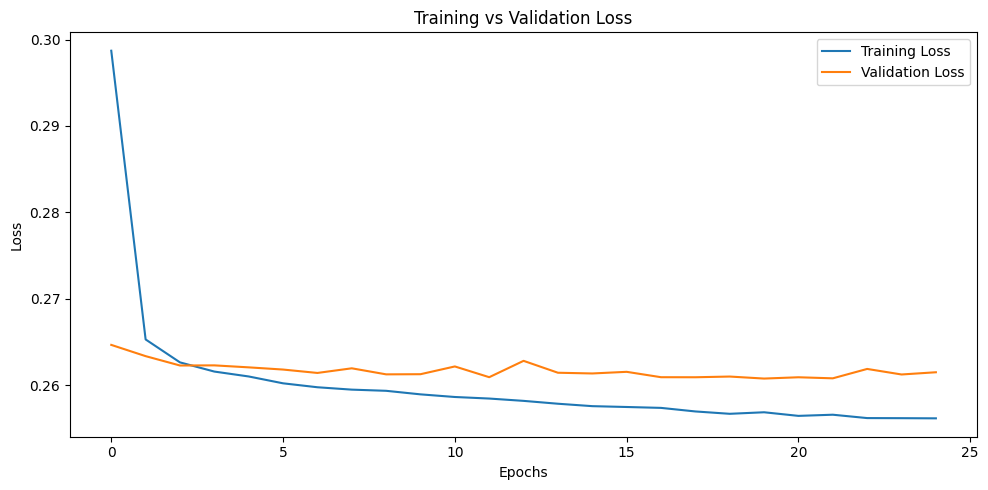

In [137]:
losses = pd.DataFrame(model.history.history)

plt.figure(figsize=(10, 5))
plt.plot(losses['loss'], label='Training Loss')
plt.plot(losses['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

In [139]:
from sklearn.metrics import classification_report, confusion_matrix

In [140]:
# Get predicted probabilities then round to 0 or 1
predictions = (model.predict(X_test) > 0.5).astype(int)

2471/2471 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [141]:
#classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.44      0.61     15658
           1       0.88      1.00      0.93     63386

    accuracy                           0.89     79044
   macro avg       0.93      0.72      0.77     79044
weighted avg       0.90      0.89      0.87     79044



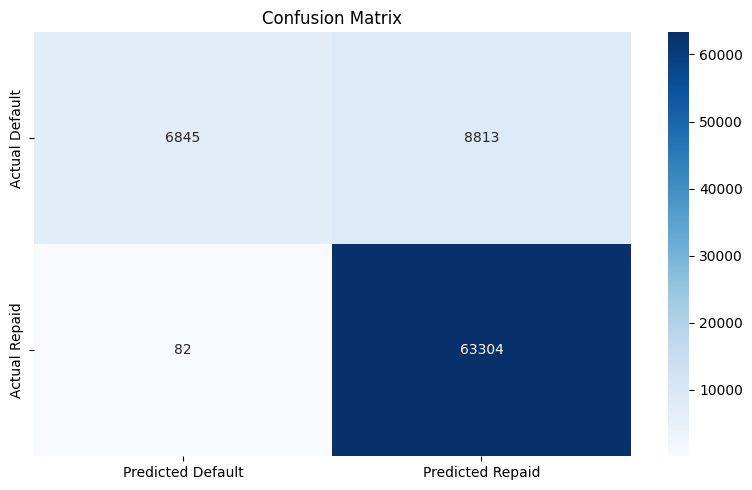

In [142]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Default', 'Predicted Repaid'],
            yticklabels=['Actual Default', 'Actual Repaid'])
plt.title('Confusion Matrix')
plt.tight_layout()

In [143]:
# Predicting on a new customer
# Pick a random customer from the dataset
# and predict whether they'll repay their loan

import random

random.seed(101)
random_ind = random.randint(0, len(df))

# Get the customer's feature data (everything except target)
new_customer = df.drop('loan_repaid', axis=1).iloc[random_ind]

print("New customer data:")
print(new_customer)

New customer data:
loan_amnt           25000.0
term                     60
int_rate              18.24
installment          638.11
annual_inc          61665.0
                     ...   
48052                 False
70466                 False
86630                 False
93700                 False
earliest_cr_year       1996
Name: 305323, Length: 78, dtype: object


In [146]:
#scaling the data, and reshaping the size
customer_scaled = scaler.transform(new_customer.values.reshape(1, -1))

prediction = (model.predict(customer_scaled) > 0.5).astype(int)
prediction
#1 means will repay, 0 means will default or chargeoff

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


array([[1]])

In [147]:
# Check the actual label
actual = df.iloc[random_ind]['loan_repaid']
actual

np.int64(1)